In [1]:
path = "/data1/lyq/lorann/test_code/LowRankKmeans/model_seed1.bin"
import matplotlib.pyplot as plt  # 使用 plt 而不是 matplotlib

In [2]:
def plot_cluster_centers(cluster_centers):
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        center = cluster_centers[i].reshape(28, 28)  # MNIST 图像尺寸为 28x28
        ax.imshow(center, cmap='gray')
        ax.axis('off')
        ax.set_title(f"簇 {i}")
    plt.tight_layout()
    plt.show()
    plt.savefig("cluster_centers_111.png")

In [3]:
import struct
import numpy as np

def load_model(filepath):
    try:
        with open(filepath, 'rb') as f:
            # 读取模型参数（假设全部为小端字节序，需根据实际情况调整）
            # 假设:
            #   n_clusters_, rank_, max_iter_, random_seed_ 为 int32
            #   tol_ 为 float32
            n_clusters_ = struct.unpack('i', f.read(4))[0]
            rank_ = struct.unpack('i', f.read(4))[0]
            max_iter_ = struct.unpack('i', f.read(4))[0]
            tol_ = struct.unpack('f', f.read(4))[0]
            random_seed_ = struct.unpack('i', f.read(4))[0]

            # 读取 A_ 的维度 (Eigen::Index 通常为 64 位整数)
            rows_A = struct.unpack('q', f.read(8))[0]
            cols_A = struct.unpack('q', f.read(8))[0]
            # 读取 A_ 数据（float32）
            A_data = struct.unpack(f'{rows_A * cols_A}f', f.read(4 * rows_A * cols_A))
            A_ = np.array(A_data, dtype=np.float32).reshape((rows_A, cols_A), order='F')

            # 读取 B_ 的维度
            rows_B = struct.unpack('q', f.read(8))[0]
            cols_B = struct.unpack('q', f.read(8))[0]
            # 读取 B_ 数据（float32）
            B_data = struct.unpack(f'{rows_B * cols_B}f', f.read(4 * rows_B * cols_B))
            B_ = np.array(B_data, dtype=np.float32).reshape((rows_B, cols_B), order='F')

            # 读取 cluster_centers_ 的维度
            rows_C = struct.unpack('q', f.read(8))[0]
            cols_C = struct.unpack('q', f.read(8))[0]
            # 读取 cluster_centers_ 数据（float32）
            cluster_data = struct.unpack(f'{rows_C * cols_C}f', f.read(4 * rows_C * cols_C))
            cluster_centers_ = np.array(cluster_data, dtype=np.float32).reshape((rows_C, cols_C), order='F')

            # 读取目标函数历史记录
            # 假设 history_size 为 size_t，对应 64 位无符号整数
            history_size = struct.unpack('Q', f.read(8))[0]
            if history_size > 0:
                history_data = struct.unpack(f'{history_size}f', f.read(4 * history_size))
                objective_history_ = np.array(history_data, dtype=np.float32)
            else:
                objective_history_ = np.array([], dtype=np.float32)

        print("模型成功加载：", filepath)
        # 打印加载后的信息，类似于 print_model_info()
        print("Model Info:")
        print(f"n_clusters_ = {n_clusters_}")
        print(f"rank_ = {rank_}")
        print(f"max_iter_ = {max_iter_}")
        print(f"tol_ = {tol_}")
        print(f"random_seed_ = {random_seed_}")
        print(f"A_.shape = {A_.shape}")
        print(f"B_.shape = {B_.shape}")
        print(f"cluster_centers_.shape = {cluster_centers_.shape}")
        print(f"objective_history_.size = {objective_history_.size}")

        return {
            "n_clusters_": n_clusters_,
            "rank_": rank_,
            "max_iter_": max_iter_,
            "tol_": tol_,
            "random_seed_": random_seed_,
            "A_": A_,
            "B_": B_,
            "cluster_centers_": cluster_centers_,
            "objective_history_": objective_history_
        }

    except Exception as e:
        print(f"加载模型时发生错误: {e}")
        return None

模型成功加载： /data1/lyq/lorann/test_code/LowRankKmeans/dataset/trained_model/mnist/model_n_clusters1024.bin
Model Info:
n_clusters_ = 1024
rank_ = 32
max_iter_ = 150
tol_ = 9.999999747378752e-05
random_seed_ = 999
A_.shape = (784, 32)
B_.shape = (32, 1024)
cluster_centers_.shape = (1024, 784)
objective_history_.size = 76


/tmp/ipykernel_41502/2638568266.py:9: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/brucelee/miniconda3/envs/faiss_custom/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


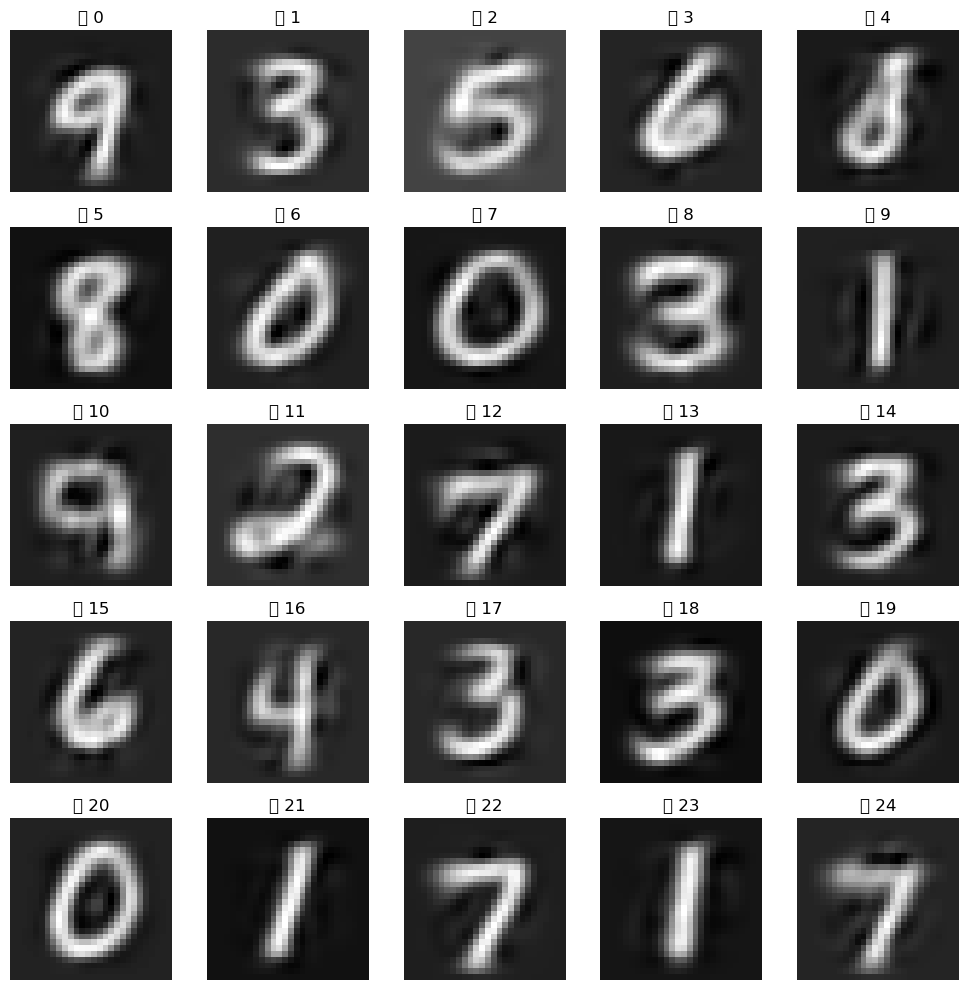

<Figure size 640x480 with 0 Axes>

In [4]:

# 示例使用
model_data = load_model("/data1/lyq/lorann/test_code/LowRankKmeans/dataset/trained_model/mnist/model_n_clusters1024.bin")
if model_data is not None:
    # 使用 model_data 中的数据
    pass
plot_cluster_centers(model_data["cluster_centers_"])

/tmp/ipykernel_41502/2638568266.py:9: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


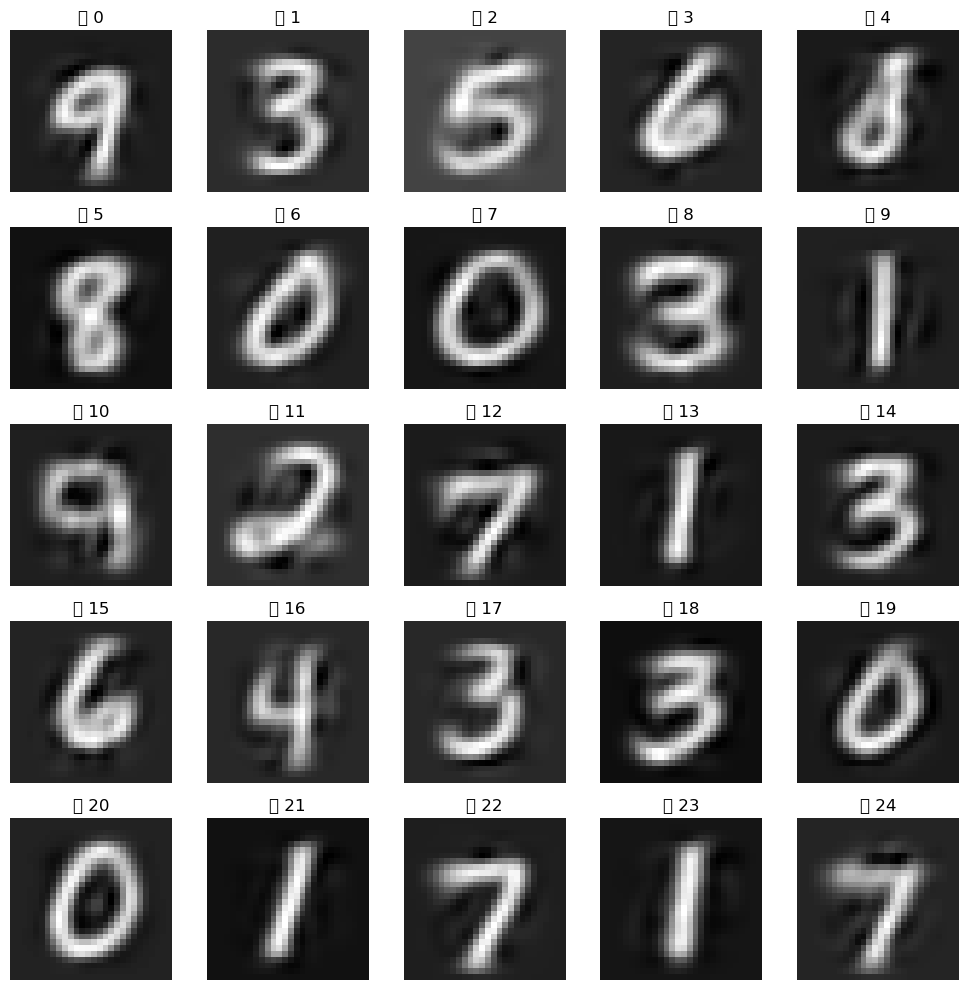

<Figure size 640x480 with 0 Axes>

In [19]:
plot_cluster_centers((model_data["A_"] @ model_data["B_"]).T)

(32, 1024)

In [20]:
A_ = model_data["A_"]
B_ = model_data["B_"]
res = (A_ @ B_).T
print(type(A_), type(B_))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [45]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances
from collections import defaultdict

def residual_kmeans(data, n_clusters, n_layers=2):
    """
    使用残差思想进行多层 K-means 聚类。
    返回每层的聚类标签、簇中心和残差。
    """
    cluster_labels_list = []
    centroids_list = []
    residuals_list = []
    current_data = data

    for layer in range(n_layers):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(current_data)
        centroids = kmeans.cluster_centers_
        residuals = current_data - centroids[cluster_labels]
        
        cluster_labels_list.append(cluster_labels)
        centroids_list.append(centroids)
        residuals_list.append(residuals)
        
        current_data = residuals
        
    return cluster_labels_list, centroids_list, residuals_list

def build_ivf(cluster_labels_list, centroids_list):
    """
    基于聚类结果构建多层倒排索引。
    """
    ivf = []
    for layer, cluster_labels in enumerate(cluster_labels_list):
        layer_ivf = defaultdict(list)
        for i, cluster_id in enumerate(cluster_labels):
            layer_ivf[cluster_id].append(i)
        ivf.append(layer_ivf)
    return ivf

def topk_search(query, data, ivf, centroids_list, residuals_list, k=5, residual_weight=0.5):
    """
    在多层倒排索引上执行 Top-k 近邻搜索。
    使用多层筛选、残差权重和距离筛选。
    """
    candidate_indices = set(range(len(data)))
    
    for layer, layer_ivf in enumerate(ivf):
      if not candidate_indices:
        break
        
      distances = pairwise_distances(query, centroids_list[layer])
      
      
      closest_centroid_ids = np.argsort(distances)[0][:3]  # 保留最近的3个簇
      
      new_candidates = set()
      for centroid_id in closest_centroid_ids:
          new_candidates.update(layer_ivf.get(centroid_id,[]))
      
      # 计算残差距离
      residual_distances = {}
      if layer < len(residuals_list):
        for idx in new_candidates:
            residual_distances[idx] = np.linalg.norm(query - centroids_list[layer][cluster_labels_list[layer][idx]] - residuals_list[layer][idx])
      else:
        for idx in new_candidates:
           residual_distances[idx] = np.linalg.norm(query - centroids_list[layer-1][cluster_labels_list[layer-1][idx]] )
           
        
      
      
      # 根据距离和残差权重筛选
      weighted_distances = {}
      for idx in new_candidates:
        weighted_distances[idx] = (1-residual_weight)* distances[0][cluster_labels_list[layer][idx]] + residual_weight * residual_distances[idx] if layer < len(residuals_list) else distances[0][cluster_labels_list[layer-1][idx]]
          
      sorted_candidates = sorted(weighted_distances.items(), key=lambda item: item[1])
      
      candidate_indices = candidate_indices.intersection(set([item[0] for item in sorted_candidates[:int(len(new_candidates)*0.8)]])) # 采用距离排序，保留80%的候选集
      
    if not candidate_indices:
      return []
    
    candidate_data = data[list(candidate_indices)]
    distances = pairwise_distances(query, candidate_data)
    topk_indices = np.argsort(distances)[0][:k]
    return list(np.array(list(candidate_indices))[topk_indices])

def evaluate_topk(data, ivf, centroids_list, residuals_list, k=5, num_queries=100, residual_weight=0.5):
    """
    评估 Top-k 近邻搜索的准确率。
    """
    total_accuracy = 0
    for _ in range(num_queries):
        query_index = np.random.randint(0, len(data))
        query = data[query_index].reshape(1, -1) 

        true_distances = pairwise_distances(query, data)
        true_topk_indices = np.argsort(true_distances)[0][1:k+1]  # Exclude the query itself
        
        
        predicted_topk_indices = topk_search(query, data, ivf, centroids_list, residuals_list, k=k, residual_weight=residual_weight)

        if predicted_topk_indices:
          
          correct_count = sum(1 for idx in predicted_topk_indices if idx in true_topk_indices)
          accuracy = correct_count / min(k, len(predicted_topk_indices))
          total_accuracy += accuracy
        
    return total_accuracy / num_queries if num_queries else 0

if __name__ == "__main__":
    # 生成模拟数据
    data, _ = make_blobs(n_samples=1000, centers=5, n_features=10, random_state=42)

    # 参数
    n_clusters = 10
    n_layers = 2
    k = 5
    residual_weight = 0.5
    # 单层 IVF
    cluster_labels_single, centroids_single, residuals_single = residual_kmeans(data, n_clusters, n_layers=1)
    ivf_single = build_ivf(cluster_labels_single, centroids_single)

    accuracy_single = evaluate_topk(data, ivf_single, centroids_single, residuals_single ,k=k, residual_weight=residual_weight)

    # 多层 IVF
    cluster_labels_multi, centroids_multi, residuals_multi = residual_kmeans(data, n_clusters, n_layers=n_layers)
    ivf_multi = build_ivf(cluster_labels_multi, centroids_multi)
    accuracy_multi = evaluate_topk(data, ivf_multi, centroids_multi, residuals_multi, k=k, residual_weight=residual_weight)

    print(f"单层 IVF Top-{k} 准确率: {accuracy_single:.4f}")
    print(f"多层 IVF Top-{k} 准确率: {accuracy_multi:.4f}")


NameError: name 'cluster_labels_list' is not defined

In [32]:
re_c = (model_data["A_"] @ model_data["B_"]).T

In [33]:
model_data["cluster_centers_"][0]

array([ 9.23725202e-06,  6.98111471e-05,  5.36120147e-04,  1.73156965e-03,
        4.20174049e-03,  5.41481934e-03,  4.66868188e-03,  1.20544783e-03,
        4.46350488e-04,  7.40938354e-03,  6.09319331e-03, -4.71105464e-02,
       -4.64739725e-02,  6.36223936e-03,  3.32765356e-02,  2.02598460e-02,
        5.39333150e-02,  8.09810013e-02,  7.14796409e-02,  5.70928231e-02,
        5.44084422e-02,  5.99405244e-02,  6.27133027e-02,  5.46649918e-02,
        3.14901546e-02,  1.72361974e-02,  6.25609607e-03,  9.04382381e-04,
        1.11283691e-04,  4.55112138e-04,  2.44861958e-03,  8.53038859e-03,
        1.62161179e-02,  2.34036986e-02,  1.83349382e-02, -5.28495526e-03,
       -2.10558018e-03,  1.42846042e-02, -8.04270618e-03, -5.43619059e-02,
        2.28247475e-02,  6.89102560e-02,  7.18239844e-02,  1.20973915e-01,
        1.81471080e-01,  2.33011648e-01,  2.17997462e-01,  2.16823846e-01,
        2.24835321e-01,  2.55380630e-01,  2.54527748e-01,  2.25860402e-01,
        1.51928514e-01,  

In [34]:
re_c[0]

array([ 9.23725293e-06,  6.98111326e-05,  5.36120147e-04,  1.73156965e-03,
        4.20173956e-03,  5.41481981e-03,  4.66868142e-03,  1.20544783e-03,
        4.46348684e-04,  7.40938867e-03,  6.09319704e-03, -4.71105464e-02,
       -4.64739613e-02,  6.36224402e-03,  3.32765318e-02,  2.02598535e-02,
        5.39333299e-02,  8.09810013e-02,  7.14796409e-02,  5.70928194e-02,
        5.44084385e-02,  5.99405169e-02,  6.27133027e-02,  5.46649918e-02,
        3.14901546e-02,  1.72361992e-02,  6.25609653e-03,  9.04382498e-04,
        1.11283691e-04,  4.55112080e-04,  2.44861981e-03,  8.53038859e-03,
        1.62161198e-02,  2.34036986e-02,  1.83349382e-02, -5.28495619e-03,
       -2.10560090e-03,  1.42846061e-02, -8.04270245e-03, -5.43618985e-02,
        2.28247438e-02,  6.89102560e-02,  7.18239769e-02,  1.20973930e-01,
        1.81471094e-01,  2.33011663e-01,  2.17997506e-01,  2.16823831e-01,
        2.24835306e-01,  2.55380630e-01,  2.54527748e-01,  2.25860402e-01,
        1.51928514e-01,  

In [100]:
model_data["A_"][0]

array([ 9.73377828e-05, -2.68816439e-05, -2.40063218e-05, -1.45325976e-06,
        3.29626710e-05,  2.88835563e-05,  1.10260698e-05, -3.33296839e-06,
        9.33326533e-07,  3.54652148e-05, -2.63471011e-05,  6.15095487e-05,
        5.25288051e-05,  1.54768277e-05,  1.90845112e-05,  6.17639089e-05,
        4.95512504e-05, -8.11966893e-05, -3.40350271e-05, -1.28233278e-05,
       -1.77504371e-05,  1.73990811e-05, -1.02963395e-05, -5.04021409e-05,
        2.24649266e-05, -2.24329287e-05,  5.78650688e-05,  2.13232288e-05,
       -3.55145748e-05, -2.71063964e-05,  7.32435183e-06, -1.21536850e-05],
      dtype=float32)

In [103]:
dataset[1] @ (model_data["A_"])

UFuncTypeError: ufunc 'matmul' did not contain a loop with signature matching types (dtype('<U1'), dtype('float32')) -> None

In [60]:
 model_data["B_"].shape

(32, 1024)

In [85]:
import h5py
from urllib.request import urlretrieve
# read the data set
dataset = "fashion-mnist-784-euclidean"

def download(source_url, destination_path):
    if not os.path.exists(destination_path):
        print(f"downloading {source_url} -> {destination_path}...")
        urlretrieve(source_url, destination_path)
download("http://ann-benchmarks.com/%s.hdf5" % dataset, "%s.hdf5" % dataset)

f = h5py.File("%s.hdf5" % dataset, "r")
train = f["train"][:]/ 255.0
test = f["test"][:]/ 255.0

In [108]:
test[1]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.05098039, 0.2627451 , 0.        , 0.        , 0.        ,
       0.        , 0.19607843, 0.14901961, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.03137255, 0.47058824, 0.81960785, 0.8862745 , 0.96862745,
       0.92941177, 1.        , 1.        , 1.        , 0.96862745,
       0.93333334, 0.92156863, 0.6745098 , 0.28235295, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.5372549 , 0.9372549 , 0.9882353 ,
       0.9529412 , 0.91764706, 0.8980392 , 0.93333334, 0.95686275,
       0.9647059 , 0.9411765 , 0.9019608 , 0.9098039 , 0.93725

In [114]:
-2 * test[1] @ model_data["A_"]  @ model_data["B_"]

array([ -99.43773, -300.82275, -184.16673, ..., -425.0165 , -212.25307,
       -287.68564], dtype=float32)

In [106]:
model_data["A_"].shape

(784, 32)

In [115]:
model_data["B_"][0]

array([0.00854148, 0.04428515, 0.02003917, ..., 0.0431995 , 0.0250597 ,
       0.03907342], dtype=float32)

In [11]:
print(A.shape, B.shape)
(B.T @ A.T)[0][0]

(784, 32) (32, 1024)


-8.292561e-07

In [113]:
model_data["A_"][0]

array([ 9.73377828e-05, -2.68816439e-05, -2.40063218e-05, -1.45325976e-06,
        3.29626710e-05,  2.88835563e-05,  1.10260698e-05, -3.33296839e-06,
        9.33326533e-07,  3.54652148e-05, -2.63471011e-05,  6.15095487e-05,
        5.25288051e-05,  1.54768277e-05,  1.90845112e-05,  6.17639089e-05,
        4.95512504e-05, -8.11966893e-05, -3.40350271e-05, -1.28233278e-05,
       -1.77504371e-05,  1.73990811e-05, -1.02963395e-05, -5.04021409e-05,
        2.24649266e-05, -2.24329287e-05,  5.78650688e-05,  2.13232288e-05,
       -3.55145748e-05, -2.71063964e-05,  7.32435183e-06, -1.21536850e-05],
      dtype=float32)

In [17]:
B[0]

array([ 1.0868316 , -0.00911464,  1.2122916 , ...,  0.72806114,
        1.089496  ,  1.3268732 ], dtype=float32)

In [12]:
import torch



In [ ]:
sum(counts)

69995

In [ ]:
counts.max()

285

In [ ]:
counts.min()

1

In [ ]:
dataset[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.33333334,
       0.5372549 , 0.64705884, 0.87058824, 0.7764706 , 0.7254902 ,
       0.74509805, 0.7607843 , 0.6627451 , 0.4392157 , 0.22745098,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00392157, 0.        ,
       0.09019608, 0.69803923, 0.8784314 , 0.84313726, 0.59607846,
       0.6431373 , 0.7372549 , 0.8117647 , 0.8392157 , 0.75686276,
       0.6       , 0.8156863 , 0.89411765, 0.60784316, 0.        ,
       0.        , 0.01176471, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.7490196 , 0.7607843 ,
       0.5686275 , 0.7882353 , 1.        , 0.7372549 , 0.5803922 ,
       0.48235294, 0.4117647 , 0.54901963, 0.6392157 , 0.84313

In [ ]:
data_norm_squared = np.sum(np.square(dataset), axis=1)
print(data_norm_squared)

[279.898    123.75488   86.77844  ...  46.690735  83.184265 127.99978 ]


In [ ]:
dataset[0].dot(dataset[0])  # 1 23225 21231 55698 20583 69784 56281   899 66027 43857

279.89798

In [64]:
dataset[0].reshape(28,28) # 0 20260 45613 26854 19414 69810 14074 64600 55072 24147  # 0 20260 45613 26854 19414 69810 14074 64600 55072 24147

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.33333334,
        0.5372549 , 0.64705884, 0.87058824, 0.7764706 , 0.7254902 ,
        0.74509805, 0.7607843 , 0.6627451 , 0.4392157 , 0.22745098,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00392157, 0.        , 0.09019608, 0.69803923, 0.8784314 ,
        0.84313726, 0.59607846, 0.6431373 , 0.7372549 , 0.8117647 ,
        0.8392157 , 0.75686276, 0.6       , 0.8156863 , 0.89411765,
        0.60784316, 0.        , 0.        , 0.01176471, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.7490196 , 0.7607843 , 0.5686275 ,
        0.7882353 , 1.        , 0.7372549 , 0.5803922 , 0.48235294,
        0.4117647 , 0.5490